# Temperature measurement of quantum chips

Try found possible way to measure temperature on chip.
The basic idea is to design proper quantum bit to reveal temperature changes.

In [2]:
from typing import (
    Any,
    Union,
)

In [14]:
import numpy as np
import pandas as pd
import scipy as sp
from scipy import constants
from matplotlib.figure import Figure
import matplotlib.pylab as plt

print(f'Import numpy V{np.__version__}')
print(f'Import pandas V{pd.__version__}')
print(f'Import scipy V{sp.__version__}')

Import numpy V1.23.5
Import pandas V1.4.3
Import scipy V1.10.1


## Prepare posibility function

In [6]:
def possibility_thermal_excitation(
        freq_excitation: Union[float, np.ndarray], 
        temperature: Union[float, np.ndarray]
) -> Union[float, np.ndarray]:
    if isinstance(freq_excitation, float) and \
            isinstance(temperature, float) and \
            temperature > 0.0 and freq_excitation > 0.0:
        return 1.0 / \
            (np.exp(constants.h * freq_excitation /
                    constants.Boltzmann / temperature) - 1.0)
    elif isinstance(freq_excitation, np.ndarray) and \
            isinstance(temperature, float) and \
            temperature > 0.0:
        posibility = np.zeros_like(freq_excitation)
        valids = freq_excitation > 0.0
        factor = constants.h / constants.Boltzmann / temperature
        posibility[valids] = 1.0 / \
            (np.exp(freq_excitation[valids] * factor) - 1.0)
        return posibility
    elif isinstance(freq_excitation, float) and \
            isinstance(temperature, np.ndarray) and \
            freq_excitation > 0.0:
        posibility = np.zeros_like(temperature)
        valids = temperature > 0.0
        factor = freq_excitation * constants.h / constants.Boltzmann
        posibility[valids] = 1.0 / \
            (np.exp(factor / temperature[valids]) - 1.0)
        return posibility
    elif isinstance(freq_excitation, np.ndarray) and \
            isinstance(temperature, np.ndarray) and \
            freq_excitation.shape == temperature.shape:
        posibility = np.zeros_like(freq_excitation)
        valids = (freq_excitation > 0.0) & (temperature > 0.0)
        factor = constants.h / constants.Boltzmann
        posibility[valids] = 1.0 / (np.exp(freq_excitation[valids] / 
                                           temperature[valids] * factor) - 1.0)
        return posibility
    raise ValueError(f'Invalid input {freq_excitation} and {temperature}')

In [8]:
possibility_thermal_excitation(5.5e9, 60e-3)

0.012438681400911852

In [18]:
def draw_possibility_on_temperature(
        freq_excitaion: float, 
        temperatures: np.ndarray
) -> [np.ndarray, Figure]:
    if not isinstance(freq_excitaion, float) or freq_excitaion < 1e-6:
        raise ValueError(f'Invalid frequency {freq_excitaion}')
    if not isinstance(temperatures, np.ndarray):
        raise TypeError(f'Invalid temperature type {type(temperatures)}')
    shape = temperatures.shape
    if len(shape) == 1 or \
            (len(shape) == 2 and (shape[0] == 1 or shape[1] == 1)):
        possibilities = possibility_thermal_excitation(freq_excitaion, 
                                                       temperatures)
        fig = plt.figure(figsize=(10, 7))
        plt.xlabel('Temperature (mK)')
        plt.ylabel('Possibility (%)')
        plt.title(f'Frequency: {freq_excitaion * 1e-9}GHz')
        plt.plot(temperatures * 1e3, possibilities * 100.0)
        return possibilities, fig
    raise ValueError(f'Invalid shape of temperatues: {shape}')

## Try normal quantum qubit

In [9]:
temperatures = np.linspace(1e-3, 30e-3, 31, True)
print(f'Prepare temperature sequence: {temperatures}')

Prepare temperature sequence: [0.001      0.00196667 0.00293333 0.0039     0.00486667 0.00583333
 0.0068     0.00776667 0.00873333 0.0097     0.01066667 0.01163333
 0.0126     0.01356667 0.01453333 0.0155     0.01646667 0.01743333
 0.0184     0.01936667 0.02033333 0.0213     0.02226667 0.02323333
 0.0242     0.02516667 0.02613333 0.0271     0.02806667 0.02903333
 0.03      ]


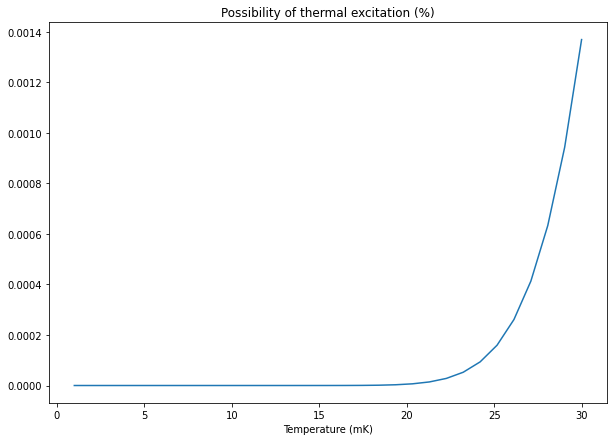

In [12]:
freq = 6.0e9
possibilities = possibility_thermal_excitation(freq, temperatures)
plt.figure(figsize=(10, 7))
plt.xlabel('Temperature (mK)')
plt.title('Possibility of thermal excitation (%)')
plt.plot(temperatures * 1e3, possibilities * 100.0)
plt.show()

C:\Users\prett\AppData\Local\Temp\ipykernel_30136\2769671397.py:2: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


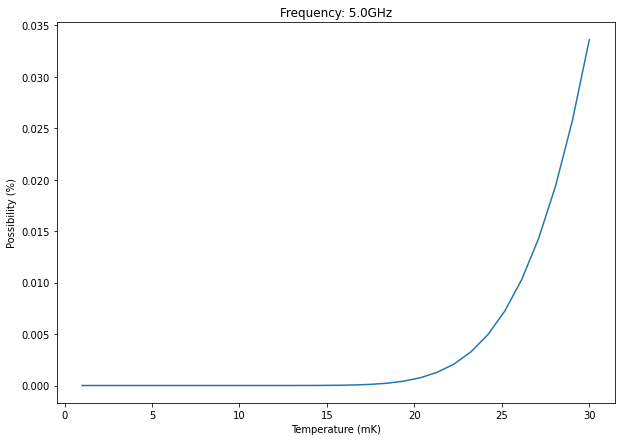

In [19]:
_, fig = draw_possibility_on_temperature(5.0e9, temperatures)
fig.show()

## Try to find proper frequency

C:\Users\prett\AppData\Local\Temp\ipykernel_30136\2873615184.py:2: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


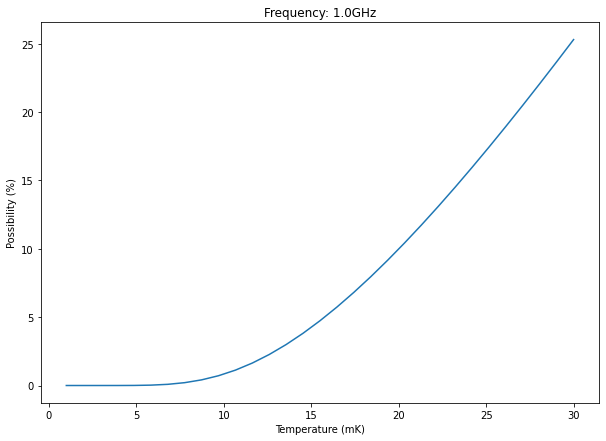

In [20]:
_, fig = draw_possibility_on_temperature(1.0e9, temperatures)
fig.show()

C:\Users\prett\AppData\Local\Temp\ipykernel_30136\1710269581.py:2: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


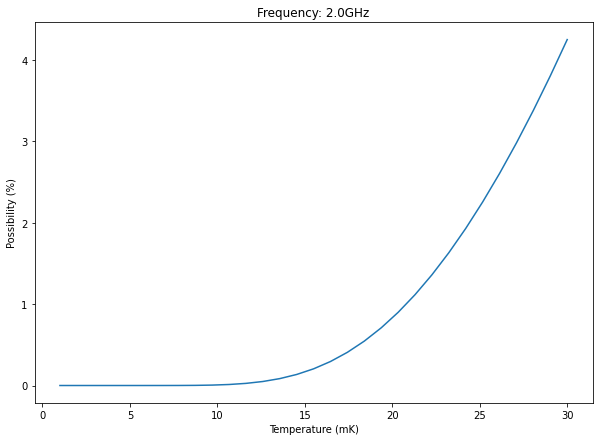

In [21]:
_, fig = draw_possibility_on_temperature(2.0e9, temperatures)
fig.show()

C:\Users\prett\AppData\Local\Temp\ipykernel_30136\3301930566.py:2: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


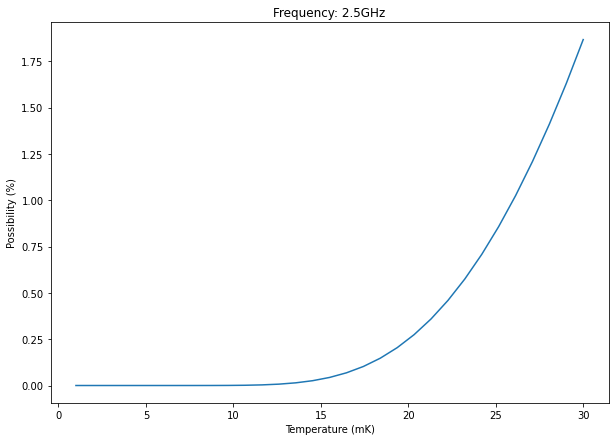

In [22]:
_, fig = draw_possibility_on_temperature(2.5e9, temperatures)
fig.show()

C:\Users\prett\AppData\Local\Temp\ipykernel_30136\3903512683.py:2: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


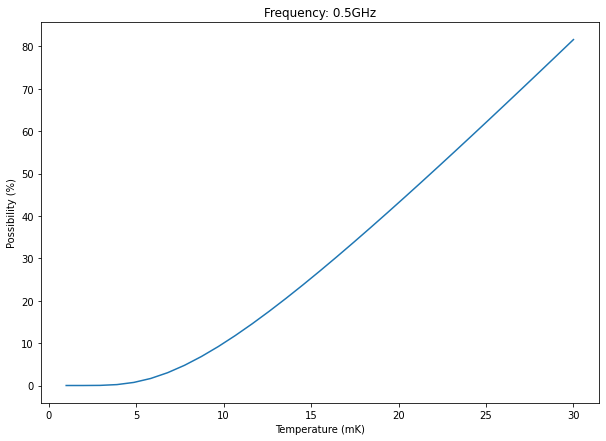

In [23]:
_, fig = draw_possibility_on_temperature(0.5e9, temperatures)
fig.show()

## Modification on qubit

Cause $\omega = \sqrt{8 E_j E_c} - E_c$, we have

$$\frac{\partial\omega}{\partial E_c} = \sqrt{\frac{2 E_j}{E_c}} - 1$$

Since $E_j \gg E_c$, we have 

$$\frac{\partial\omega}{\partial E_c} \gg 0$$

Consequently, to decrease $\omega$, it suffices to reduce size of capacity,
which leads to smaller size.

In [28]:
def calc_capacity_ratio(freq_ratio: float):
    sqrt_fc = 10.0 * np.sqrt(2.0) - \
        np.sqrt(200.0 - (20 * np.sqrt(2.0) - 1.0) / 5.0)
    return sqrt_fc * sqrt_fc

In [29]:
calc_capacity_ratio(1.0 / 5.0)

0.03773818249202579